<a href="https://www.kaggle.com/code/mawawazir/penguin-species-prediction?scriptVersionId=350495427" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


<div style="background: linear-gradient(135deg, #159090 0%, #0d5c8c 100%); padding:40px 35px; border-radius:18px; box-shadow: 0 10px 30px rgba(21,144,144,0.35); margin-bottom:20px;">
  <h1 style="color:#ffffff; font-family:'Trebuchet MS', sans-serif; font-size:38px; margin:0 0 10px 0; text-shadow: 1px 1px 6px rgba(0,0,0,0.25);">
    🐧 Penguin Species Prediction — Full EDA & Multiclass Classification
  </h1>
  <p style="color:#eafcfc; font-family:'Trebuchet MS', sans-serif; font-size:17px; margin:0; line-height:1.6;">
    A complete, beginner-friendly walkthrough of a <b>Palmer-Penguins-style</b> dataset — cleaning messy
    measurements, exploring what makes each species unique, and training a model that can tell
    <b>Adelie</b>, <b>Chinstrap</b> and <b>Gentoo</b> penguins apart from a few body measurements alone.
  </p>
  <div style="margin-top:18px;">
    <span style="background:#ffffff22; color:#fff; padding:6px 14px; border-radius:20px; font-size:13px; margin-right:8px; font-family:monospace;">📊 1000 penguins</span>
    <span style="background:#ffffff22; color:#fff; padding:6px 14px; border-radius:20px; font-size:13px; margin-right:8px; font-family:monospace;">🧬 6 features</span>
    <span style="background:#ffffff22; color:#fff; padding:6px 14px; border-radius:20px; font-size:13px; margin-right:8px; font-family:monospace;">🎯 3-class target: species</span>
    <span style="background:#ffffff22; color:#fff; padding:6px 14px; border-radius:20px; font-size:13px; font-family:monospace;">🏝️ Domain: Ecology</span>
  </div>
</div>

<div style="background:#f4fbfb; border-left:6px solid #159090; padding:18px 22px; border-radius:10px; font-family:'Trebuchet MS', sans-serif; color:#1f2a44; margin-bottom:20px;">
<b>About the dataset:</b> Each row describes one penguin observed across three islands in the Palmer
Archipelago: its <b>species</b>, the <b>island</b> it was found on, four physical measurements
(<code>culmen_length_mm</code>, <code>culmen_depth_mm</code>, <code>flipper_length_mm</code>,
<code>body_mass_g</code>), and its <b>sex</b>. The culmen is the upper ridge of a penguin's bill — its length
and depth are surprisingly powerful clues for telling species apart. Our goal: predict <code>species</code>
from the other columns.
</div>

<div style="background:#fff8e6; border-left:6px solid #f5a623; padding:16px 22px; border-radius:10px; font-family:'Trebuchet MS', sans-serif; color:#5c4400; margin-bottom:10px;">
📌 <b>What this notebook covers:</b> data cleaning → exploratory data analysis → visual storytelling → feature
preprocessing → training & comparing multiclass ML models → evaluating the best model → key takeaways.
</div>



<div style="background:#ffffff; border:1px solid #e3e8f0; border-radius:14px; padding:22px 26px; font-family:'Trebuchet MS', sans-serif;">
<h3 style="color:#159090; margin-top:0;">📑 Table of Contents</h3>
<ol style="line-height:2.1; color:#1f2a44; font-size:15px;">
<li><a href="#imports" style="text-decoration:none; color:#159090;">Setup & Imports</a></li>
<li><a href="#load" style="text-decoration:none; color:#159090;">Loading the Data</a></li>
<li><a href="#clean" style="text-decoration:none; color:#159090;">Data Cleaning</a></li>
<li><a href="#stats" style="text-decoration:none; color:#159090;">Statistical Summary</a></li>
<li><a href="#eda" style="text-decoration:none; color:#159090;">Exploratory Data Analysis</a></li>
<li><a href="#corr" style="text-decoration:none; color:#159090;">Correlation Analysis</a></li>
<li><a href="#prep" style="text-decoration:none; color:#159090;">Preprocessing for Machine Learning</a></li>
<li><a href="#model" style="text-decoration:none; color:#159090;">Model Training & Comparison</a></li>
<li><a href="#eval" style="text-decoration:none; color:#159090;">Evaluating the Best Model</a></li>
<li><a href="#conclusion" style="text-decoration:none; color:#159090;">Key Insights & Conclusion</a></li>
<li><a href="#author" style="text-decoration:none; color:#159090;">Closing Note</a></li>
</ol>
</div>



<a id="imports"></a>
<div style="background:linear-gradient(90deg,#159090,#0d5c8c); padding:14px 22px; border-radius:10px; margin-top:25px;">
<h2 style="color:#fff; font-family:'Trebuchet MS', sans-serif; margin:0;">🔧 1. Setup & Imports</h2>
</div>

<p style="font-family:'Trebuchet MS', sans-serif; color:#333;">
We start by importing the libraries we'll need: <b>pandas/numpy</b> for data handling, <b>matplotlib/seaborn</b>
for visualization, and <b>scikit-learn</b> for preprocessing, modeling and evaluation. We'll also define the
classic three-color <b>species palette</b> used across the Palmer Penguins community so our charts are easy
to read at a glance.
</p>


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "#444444"
plt.rcParams["font.family"] = "sans-serif"

# Classic Palmer Penguins species color palette
species_palette = {"Adelie": "#FF8C00", "Chinstrap": "#A034F0", "Gentoo": "#159090"}

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!



<div style="background:#eefbf1; border-left:5px solid #2ecc71; padding:12px 18px; border-radius:8px; font-family:'Trebuchet MS', sans-serif; color:#1b5e20;">
✔️ <b>Result summary:</b> Environment is ready — pandas, numpy, matplotlib, seaborn and scikit-learn are all loaded,
plotting style is set, and we've defined a species color palette (🧡 Adelie, 💜 Chinstrap, 🩵 Gentoo) that we'll
reuse in every chart for consistency.
</div>



<a id="load"></a>
<div style="background:linear-gradient(90deg,#159090,#0d5c8c); padding:14px 22px; border-radius:10px; margin-top:25px;">
<h2 style="color:#fff; font-family:'Trebuchet MS', sans-serif; margin:0;">📂 2. Loading the Data</h2>
</div>

<p style="font-family:'Trebuchet MS', sans-serif; color:#333;">
Let's load <code>data.csv</code> and take a first look at its shape, column names and a few sample rows.
</p>


In [2]:

df = pd.read_csv("/kaggle/input/datasets/srisyra02/penguin-species-dataset/Penguin Species Prediction Dataset.csv")
df.columns = [c.strip() for c in df.columns]

print(f"Shape of dataset: {df.shape[0]} rows  x  {df.shape[1]} columns\n")
df.head(8)


Shape of dataset: 1000 rows  x  7 columns



,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,41.1,18.4,195.0,3886.0,Female
1,Gentoo,Biscoe,50.0,15.4,217.0,4303.0,Male
2,Gentoo,Biscoe,50.0,15.1,220.0,4954.0,Female
3,Chinstrap,Dream,48.7,19.0,196.0,3739.0,Male
4,Adelie,Dream,39.0,17.8,187.0,3607.0,Male
5,Adelie,Dream,41.6,17.4,189.0,3568.0,Female
6,Adelie,Dream,41.1,16.8,192.0,3967.0,Male
7,Gentoo,Biscoe,49.6,15.0,224.0,4742.0,Male



<div style="background:#eefbf1; border-left:5px solid #2ecc71; padding:12px 18px; border-radius:8px; font-family:'Trebuchet MS', sans-serif; color:#1b5e20;">
✔️ <b>Result summary:</b> The dataset has <b>1000 penguin records</b> across <b>7 columns</b> — 6 features plus
the <code>species</code> target. Two columns (<code>island</code>, <code>sex</code>) are categorical text,
and four (culmen/flipper/body-mass measurements) are numeric.
</div>


In [3]:

print("Column data types:\n")
print(df.dtypes)
print("\nColumn descriptions:")
descriptions = {
    "species": "TARGET: penguin species (Adelie / Chinstrap / Gentoo)",
    "island": "Island where the penguin was observed (Torgersen / Biscoe / Dream)",
    "culmen_length_mm": "Length of the upper bill ridge (mm)",
    "culmen_depth_mm": "Depth of the upper bill ridge (mm)",
    "flipper_length_mm": "Flipper length (mm)",
    "body_mass_g": "Body mass (grams)",
    "sex": "Sex of the penguin (Male / Female)"
}
for k, v in descriptions.items():
    print(f"  • {k:20s} → {v}")

print("\nMissing values per column:")
print(df.isnull().sum())


Column data types:

species               object
island                object
culmen_length_mm     float64
culmen_depth_mm      float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

Column descriptions:
  • species              → TARGET: penguin species (Adelie / Chinstrap / Gentoo)
  • island               → Island where the penguin was observed (Torgersen / Biscoe / Dream)
  • culmen_length_mm     → Length of the upper bill ridge (mm)
  • culmen_depth_mm      → Depth of the upper bill ridge (mm)
  • flipper_length_mm    → Flipper length (mm)
  • body_mass_g          → Body mass (grams)
  • sex                  → Sex of the penguin (Male / Female)

Missing values per column:
species               0
island                0
culmen_length_mm     10
culmen_depth_mm      10
flipper_length_mm    10
body_mass_g          10
sex                  10
dtype: int64



<div style="background:#eefbf1; border-left:5px solid #2ecc71; padding:12px 18px; border-radius:8px; font-family:'Trebuchet MS', sans-serif; color:#1b5e20;">
✔️ <b>Result summary:</b> Every numeric measurement column and <code>sex</code> has exactly <b>10 missing values
(~1%)</b>, spread across <b>49 different rows</b> — meaning most affected rows are only missing one field.
<code>species</code> and <code>island</code> have no missing values at all, which is good news since
<code>species</code> is our target.
</div>



<a id="clean"></a>
<div style="background:linear-gradient(90deg,#159090,#0d5c8c); padding:14px 22px; border-radius:10px; margin-top:25px;">
<h2 style="color:#fff; font-family:'Trebuchet MS', sans-serif; margin:0;">🧹 3. Data Cleaning</h2>
</div>

<p style="font-family:'Trebuchet MS', sans-serif; color:#333;">
Since less than 1% of values are missing per column, we won't lose much by imputing rather than dropping rows.
We'll fill numeric measurements using the <b>median measurement for that penguin's own species</b> (smarter than
a global median, since species differ a lot in size), and fill <code>sex</code> with the overall most common value.
</p>


In [4]:

df_clean = df.copy()

numeric_cols = ["culmen_length_mm", "culmen_depth_mm", "flipper_length_mm", "body_mass_g"]

# Impute numeric columns using the median *within each species* group
for col in numeric_cols:
    df_clean[col] = df_clean.groupby("species")[col].transform(lambda s: s.fillna(s.median()))

# Impute sex with the overall mode
df_clean["sex"] = df_clean["sex"].fillna(df_clean["sex"].mode()[0])

print("Missing values remaining:", df_clean.isnull().sum().sum())
print("Final cleaned shape:", df_clean.shape)
df_clean.head()


Missing values remaining: 0
Final cleaned shape: (1000, 7)


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,41.1,18.4,195.0,3886.0,Female
1,Gentoo,Biscoe,50.0,15.4,217.0,4303.0,Male
2,Gentoo,Biscoe,50.0,15.1,220.0,4954.0,Female
3,Chinstrap,Dream,48.7,19.0,196.0,3739.0,Male
4,Adelie,Dream,39.0,17.8,187.0,3607.0,Male



<div style="background:#eefbf1; border-left:5px solid #2ecc71; padding:12px 18px; border-radius:8px; font-family:'Trebuchet MS', sans-serif; color:#1b5e20;">
✔️ <b>Result summary:</b> The dataset is now fully clean — <b>0 missing values</b> remain across all
<b>1000 rows × 7 columns</b>. Because we imputed measurements per-species rather than globally, we avoided
distorting each species' natural size distribution.
</div>



<a id="stats"></a>
<div style="background:linear-gradient(90deg,#159090,#0d5c8c); padding:14px 22px; border-radius:10px; margin-top:25px;">
<h2 style="color:#fff; font-family:'Trebuchet MS', sans-serif; margin:0;">📈 4. Statistical Summary</h2>
</div>

<p style="font-family:'Trebuchet MS', sans-serif; color:#333;">
Let's look at descriptive statistics for every numeric column, both overall and broken down by species.
</p>


In [5]:

df_clean[numeric_cols].describe().T.style.background_gradient(cmap="Blues", axis=0)


,count,mean,std,min,25%,50%,75%,max
culmen_length_mm,1000.000000,43.813050,5.302765,32.400000,39.000000,43.800000,48.300000,56.000000
culmen_depth_mm,1000.000000,17.335600,1.776758,13.000000,15.800000,17.800000,18.700000,21.400000
flipper_length_mm,1000.000000,199.225000,13.158705,175.000000,189.000000,195.000000,212.000000,235.000000
body_mass_g,1000.000000,4102.142000,703.862730,2830.000000,3593.500000,3880.000000,4587.000000,6317.000000



<div style="background:#eefbf1; border-left:5px solid #2ecc71; padding:12px 18px; border-radius:8px; font-family:'Trebuchet MS', sans-serif; color:#1b5e20;">
✔️ <b>Result summary:</b> Body mass ranges widely from ~2,830g to ~6,320g, and flipper length from 175mm to
235mm — a huge hint that we're mixing very differently-sized species together. Let's confirm that by
grouping per species next.
</div>


In [6]:

df_clean.groupby("species")[numeric_cols].mean().round(1).style.background_gradient(cmap="Greens", axis=0)


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.900000,18.300000,189.900000,3705.200000
Chinstrap,48.800000,18.300000,195.600000,3734.100000
Gentoo,47.400000,14.900000,217.300000,5058.200000



<div style="background:#eefbf1; border-left:5px solid #2ecc71; padding:12px 18px; border-radius:8px; font-family:'Trebuchet MS', sans-serif; color:#1b5e20;">
✔️ <b>Result summary:</b> <b>Gentoo</b> penguins are clearly the largest — heaviest body mass and longest
flippers by a wide margin. <b>Chinstrap</b> penguins have the longest culmen (bill), while <b>Adelie</b>
penguins have the shortest bills and smallest overall body size. These size differences are exactly what
our model will learn to exploit.
</div>



<a id="eda"></a>
<div style="background:linear-gradient(90deg,#159090,#0d5c8c); padding:14px 22px; border-radius:10px; margin-top:25px;">
<h2 style="color:#fff; font-family:'Trebuchet MS', sans-serif; margin:0;">🔍 5. Exploratory Data Analysis</h2>
</div>

<p style="font-family:'Trebuchet MS', sans-serif; color:#333;">
First, how balanced is our target variable across the three species?
</p>


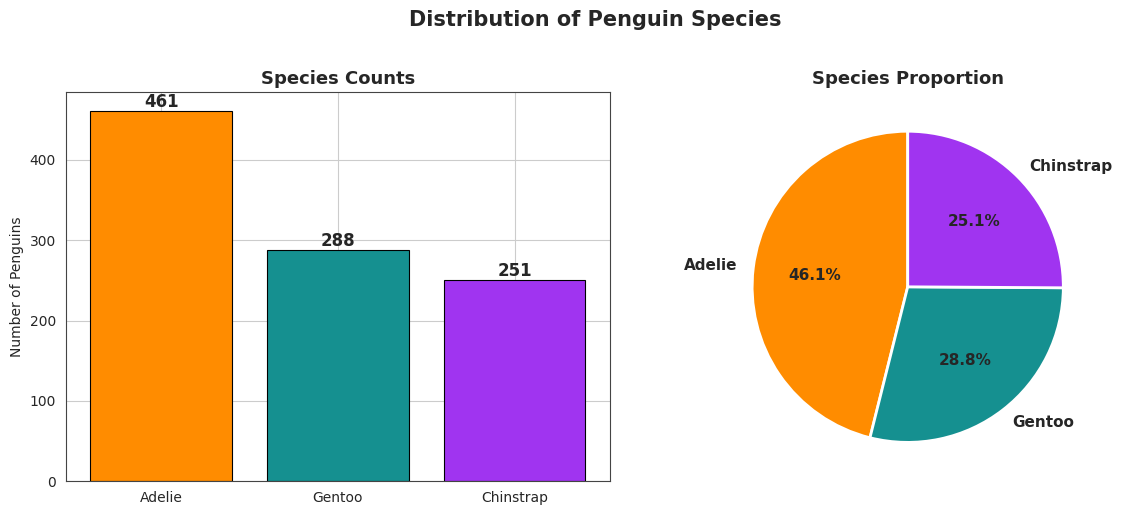

species
Adelie       461
Gentoo       288
Chinstrap    251
Name: count, dtype: int64


In [7]:

species_counts = df_clean["species"].value_counts()
colors_list = [species_palette[s] for s in species_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(species_counts.index, species_counts.values, color=colors_list, edgecolor="black", linewidth=0.8)
for i, v in enumerate(species_counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold", fontsize=12)
axes[0].set_title("Species Counts", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of Penguins")

axes[1].pie(species_counts.values, labels=species_counts.index, colors=colors_list, autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2},
            textprops={"fontsize": 11, "fontweight": "bold"})
axes[1].set_title("Species Proportion", fontsize=13, fontweight="bold")

plt.suptitle("Distribution of Penguin Species", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(species_counts)



<div style="background:#eefbf1; border-left:5px solid #2ecc71; padding:12px 18px; border-radius:8px; font-family:'Trebuchet MS', sans-serif; color:#1b5e20;">
✔️ <b>Result summary:</b> <b>Adelie</b> is the most common species (~46%), followed by <b>Gentoo</b> (~29%)
and <b>Chinstrap</b> (~25%). This is a mild class imbalance — worth keeping in mind for model evaluation,
but not severe enough to require special resampling techniques.
</div>



<p style="font-family:'Trebuchet MS', sans-serif; color:#333;">
Which islands are home to which species? This is a classic and very telling relationship in this dataset.
</p>


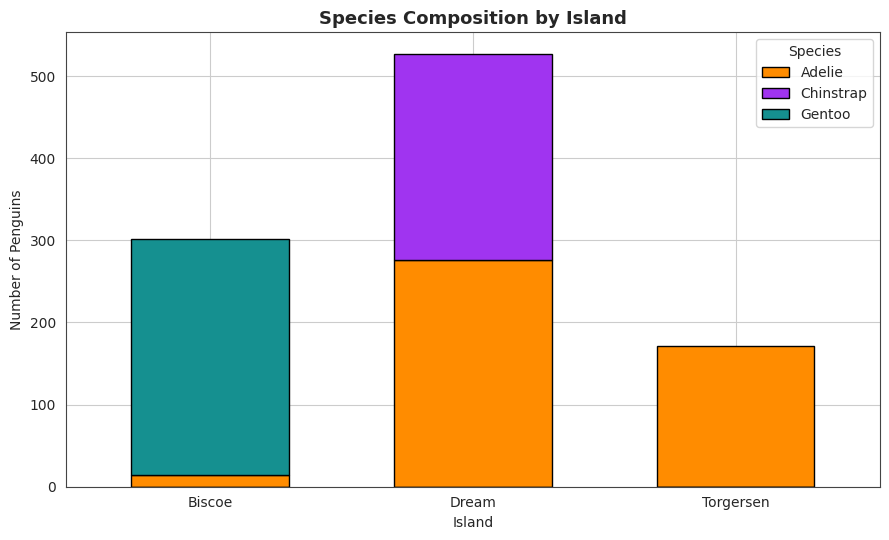

species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,14,0,288
Dream,276,251,0
Torgersen,171,0,0


In [8]:

island_species = pd.crosstab(df_clean["island"], df_clean["species"])

ax = island_species.plot(kind="bar", stacked=True,
                          color=[species_palette[c] for c in island_species.columns],
                          edgecolor="black", figsize=(9, 5.5), width=0.6)
ax.set_title("Species Composition by Island", fontsize=13, fontweight="bold")
ax.set_xlabel("Island")
ax.set_ylabel("Number of Penguins")
plt.xticks(rotation=0)
plt.legend(title="Species")
plt.tight_layout()
plt.show()

island_species



<div style="background:#eefbf1; border-left:5px solid #2ecc71; padding:12px 18px; border-radius:8px; font-family:'Trebuchet MS', sans-serif; color:#1b5e20;">
✔️ <b>Result summary:</b> <b>Torgersen</b> is home only to Adelie penguins, <b>Biscoe</b> hosts mostly Gentoo
(plus some Adelie), and <b>Dream</b> is shared between Adelie and Chinstrap. This means <code>island</code>
alone already carries strong species information, especially for ruling out Gentoo vs. Chinstrap on
Torgersen/Dream.
</div>



<p style="font-family:'Trebuchet MS', sans-serif; color:#333;">
Now for the star chart of this dataset: <b>culmen length vs. culmen depth</b>, colored by species. This
combination is famous for almost perfectly separating the three species visually.
</p>


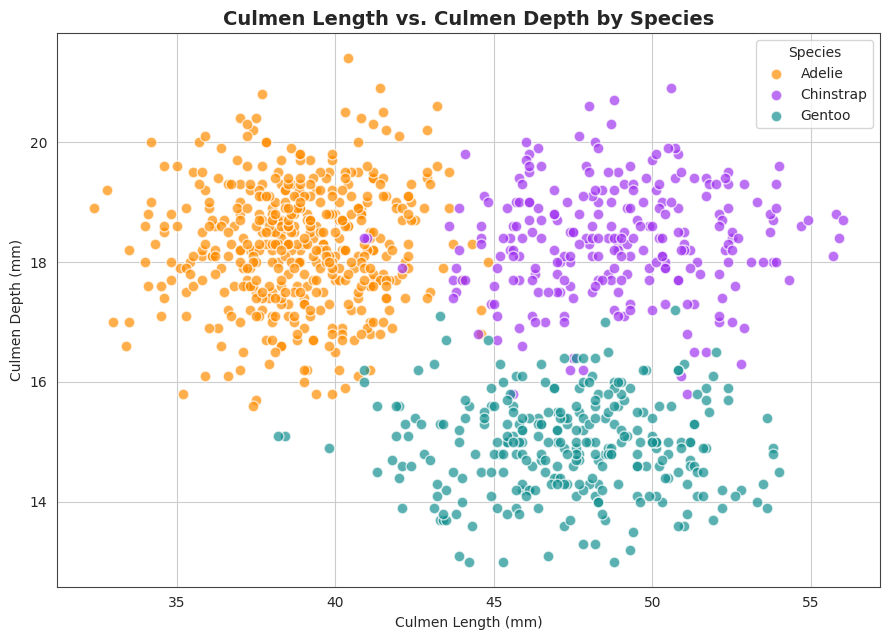

In [9]:

plt.figure(figsize=(9, 6.5))
for species, color in species_palette.items():
    subset = df_clean[df_clean["species"] == species]
    plt.scatter(subset["culmen_length_mm"], subset["culmen_depth_mm"],
                label=species, color=color, alpha=0.7, edgecolor="white", s=60)

plt.xlabel("Culmen Length (mm)")
plt.ylabel("Culmen Depth (mm)")
plt.title("Culmen Length vs. Culmen Depth by Species", fontsize=14, fontweight="bold")
plt.legend(title="Species")
plt.tight_layout()
plt.show()



<div style="background:#eefbf1; border-left:5px solid #2ecc71; padding:12px 18px; border-radius:8px; font-family:'Trebuchet MS', sans-serif; color:#1b5e20;">
✔️ <b>Result summary:</b> The three species form <b>almost entirely separate clusters</b> on this chart!
Adelie has short, deep bills; Gentoo has long, shallow bills; Chinstrap has long, deep bills. This tells us
that even a simple model using just these two features could classify species with very high accuracy.
</div>



<p style="font-family:'Trebuchet MS', sans-serif; color:#333;">
Let's also check <b>flipper length vs. body mass</b> — another pair known to separate Gentoo from the other
two species particularly well.
</p>


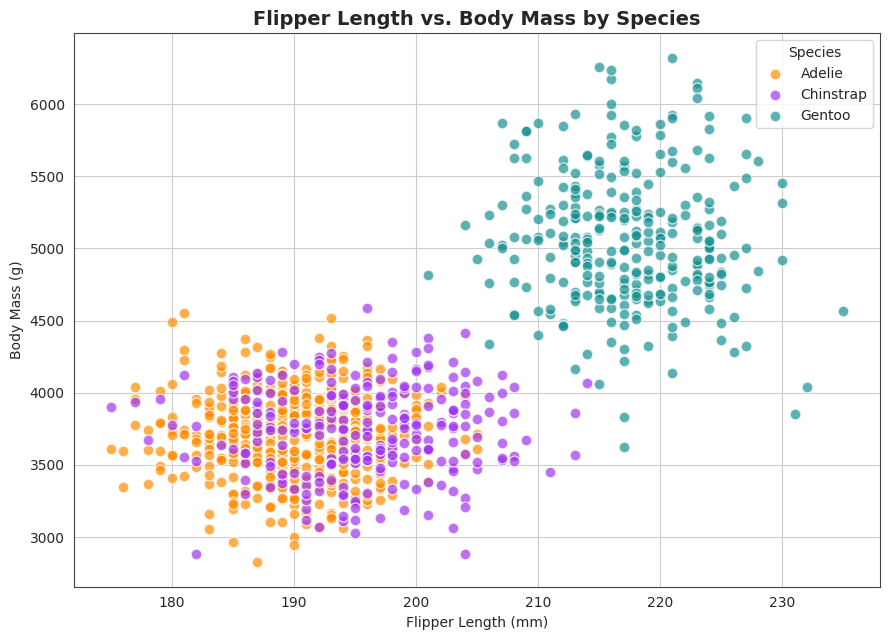

In [10]:

plt.figure(figsize=(9, 6.5))
for species, color in species_palette.items():
    subset = df_clean[df_clean["species"] == species]
    plt.scatter(subset["flipper_length_mm"], subset["body_mass_g"],
                label=species, color=color, alpha=0.7, edgecolor="white", s=60)

plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.title("Flipper Length vs. Body Mass by Species", fontsize=14, fontweight="bold")
plt.legend(title="Species")
plt.tight_layout()
plt.show()



<div style="background:#eefbf1; border-left:5px solid #2ecc71; padding:12px 18px; border-radius:8px; font-family:'Trebuchet MS', sans-serif; color:#1b5e20;">
✔️ <b>Result summary:</b> <b>Gentoo</b> penguins clearly separate from the other two species here, with
noticeably longer flippers and heavier body mass. Adelie and Chinstrap overlap more on this pair, which is
why culmen measurements (previous chart) are especially useful for telling those two apart.
</div>



<p style="font-family:'Trebuchet MS', sans-serif; color:#333;">
Let's look at the distribution of every numeric feature by species side by side using boxplots.
</p>


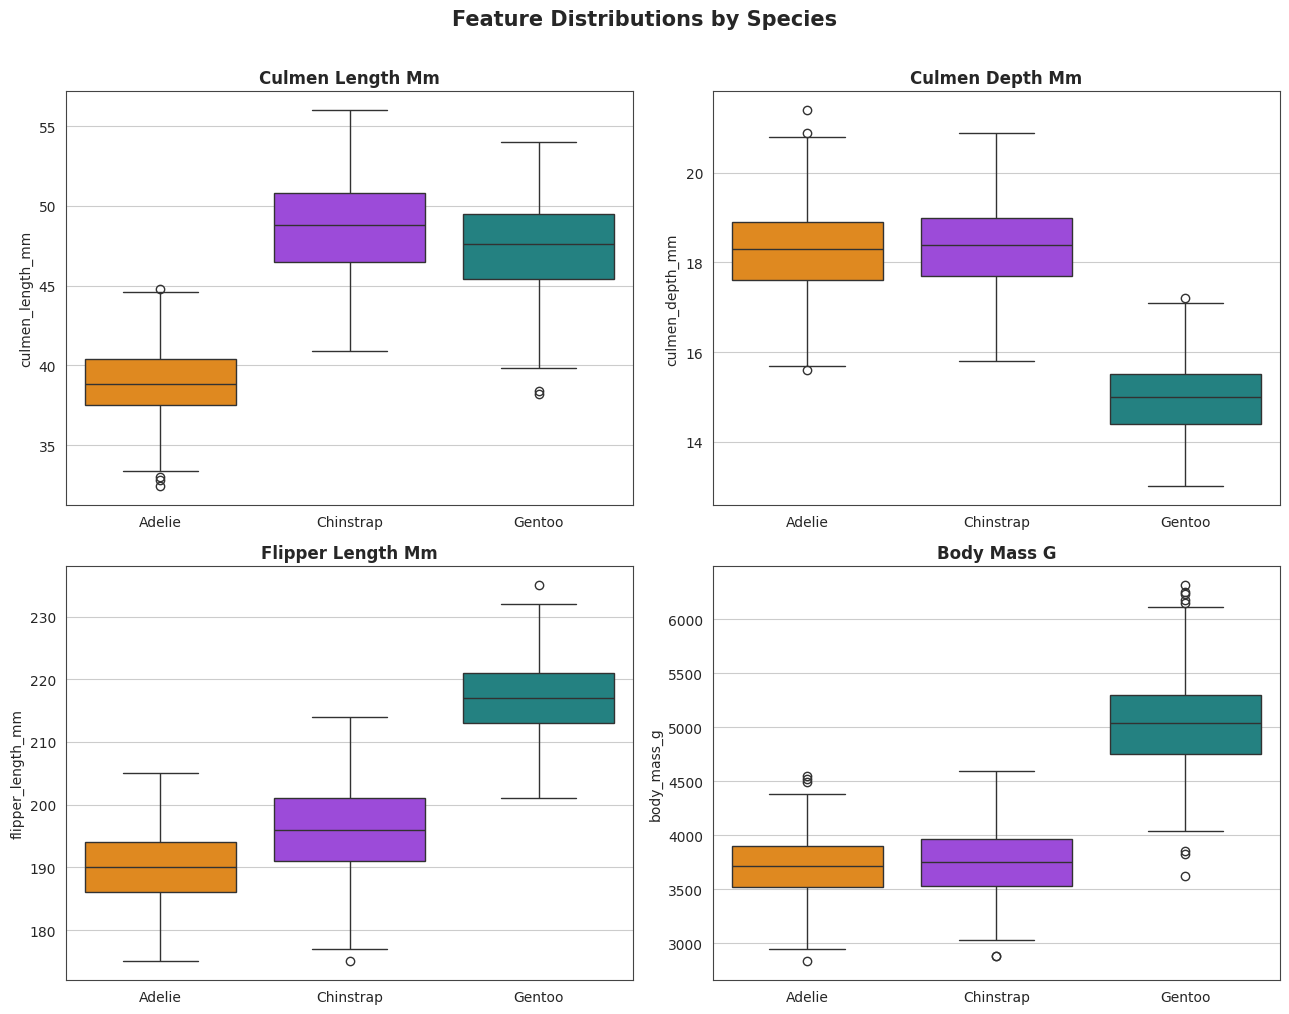

In [11]:

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df_clean, x="species", y=col, hue="species",
                palette=species_palette, legend=False, ax=axes[i],
                order=list(species_palette.keys()))
    axes[i].set_title(col.replace("_", " ").title(), fontsize=12, fontweight="bold")
    axes[i].set_xlabel("")

plt.suptitle("Feature Distributions by Species", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()



<div style="background:#eefbf1; border-left:5px solid #2ecc71; padding:12px 18px; border-radius:8px; font-family:'Trebuchet MS', sans-serif; color:#1b5e20;">
✔️ <b>Result summary:</b> Every single measurement shows a visible difference across species, with fairly
tight, well-separated boxes and few outliers. This consistently strong separation across multiple features
is a great sign for building an accurate classifier.
</div>



<p style="font-family:'Trebuchet MS', sans-serif; color:#333;">
Finally, does <b>sex</b> relate to species distribution, or is it fairly balanced within each species?
</p>


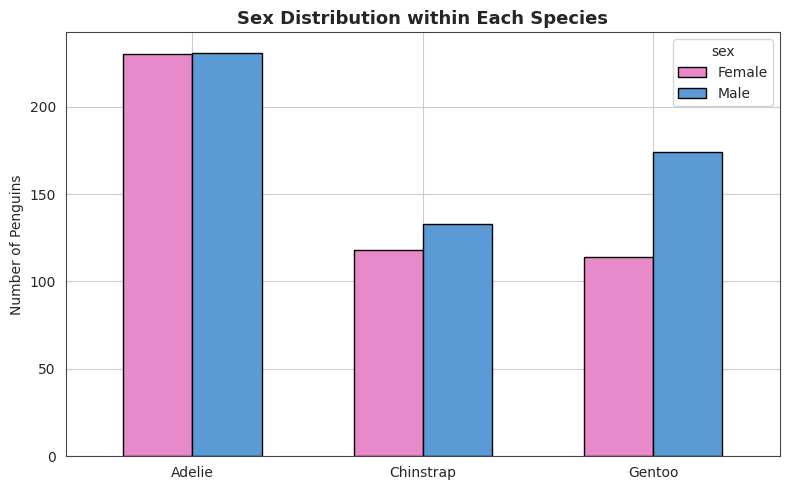

sex,Female,Male
species,,
Adelie,230,231
Chinstrap,118,133
Gentoo,114,174


In [12]:

sex_species = pd.crosstab(df_clean["species"], df_clean["sex"])
ax = sex_species.plot(kind="bar", color=["#e88ac9", "#5b9bd5"], edgecolor="black", figsize=(8, 5), width=0.6)
ax.set_title("Sex Distribution within Each Species", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Number of Penguins")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

sex_species



<div style="background:#eefbf1; border-left:5px solid #2ecc71; padding:12px 18px; border-radius:8px; font-family:'Trebuchet MS', sans-serif; color:#1b5e20;">
✔️ <b>Result summary:</b> Male and female counts are fairly balanced within each species. <code>sex</code>
likely won't be a strong standalone predictor of species, but it can still add useful nuance (males are
typically slightly larger than females across all three species).
</div>



<a id="corr"></a>
<div style="background:linear-gradient(90deg,#159090,#0d5c8c); padding:14px 22px; border-radius:10px; margin-top:25px;">
<h2 style="color:#fff; font-family:'Trebuchet MS', sans-serif; margin:0;">🔗 6. Correlation Analysis</h2>
</div>

<p style="font-family:'Trebuchet MS', sans-serif; color:#333;">
Let's check how the numeric features relate to each other with a correlation heatmap.
</p>


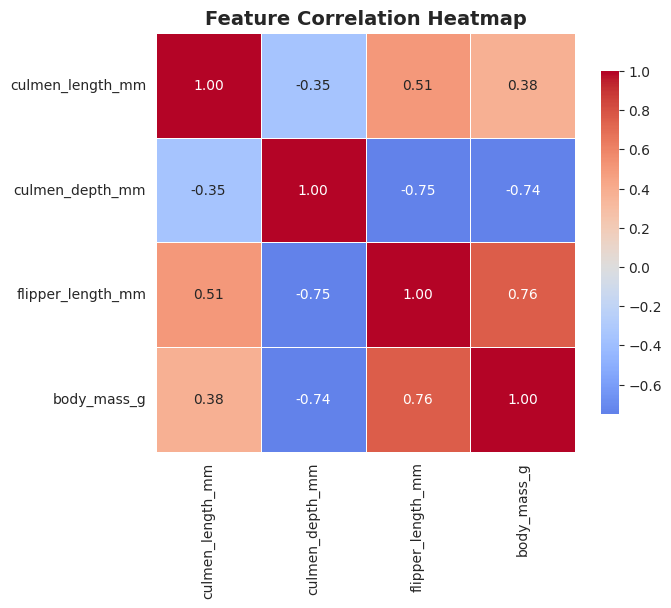

In [13]:

corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()



<div style="background:#eefbf1; border-left:5px solid #2ecc71; padding:12px 18px; border-radius:8px; font-family:'Trebuchet MS', sans-serif; color:#1b5e20;">
✔️ <b>Result summary:</b> <code>flipper_length_mm</code> and <code>body_mass_g</code> are strongly correlated
(larger penguins have longer flippers, unsurprisingly), while <code>culmen_depth_mm</code> correlates
negatively with both — consistent with Gentoo's "long flipper, shallow bill" profile we saw earlier.
No pair is so strongly correlated that we need to remove a feature before modeling.
</div>



<a id="prep"></a>
<div style="background:linear-gradient(90deg,#159090,#0d5c8c); padding:14px 22px; border-radius:10px; margin-top:25px;">
<h2 style="color:#fff; font-family:'Trebuchet MS', sans-serif; margin:0;">⚙️ 7. Preprocessing for Machine Learning</h2>
</div>

<p style="font-family:'Trebuchet MS', sans-serif; color:#333;">
We'll one-hot encode the categorical columns (<code>island</code>, <code>sex</code>), label-encode the target
species, split into train/test sets (80/20, stratified), and scale the numeric features.
</p>


In [14]:

df_model = pd.get_dummies(df_clean, columns=["island", "sex"], drop_first=True)

le = LabelEncoder()
df_model["species_encoded"] = le.fit_transform(df_model["species"])
print("Species encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

features = [c for c in df_model.columns if c not in ["species", "species_encoded"]]
X = df_model[features]
y = df_model["species_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set: {X_train.shape[0]} penguins")
print(f"Test set:     {X_test.shape[0]} penguins")
print(f"Features used ({len(features)}):", features)


Species encoding: {'Adelie': np.int64(0), 'Chinstrap': np.int64(1), 'Gentoo': np.int64(2)}

Training set: 800 penguins
Test set:     200 penguins
Features used (7): ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island_Dream', 'island_Torgersen', 'sex_Male']



<div style="background:#eefbf1; border-left:5px solid #2ecc71; padding:12px 18px; border-radius:8px; font-family:'Trebuchet MS', sans-serif; color:#1b5e20;">
✔️ <b>Result summary:</b> Data is split into <b>800 training</b> and <b>200 test</b> penguins (stratified to
preserve the species ratio in both sets). Categorical columns are now numeric dummy variables, the target is
label-encoded (0/1/2), and numeric features are standardized — everything is ready for modeling.
</div>



<a id="model"></a>
<div style="background:linear-gradient(90deg,#159090,#0d5c8c); padding:14px 22px; border-radius:10px; margin-top:25px;">
<h2 style="color:#fff; font-family:'Trebuchet MS', sans-serif; margin:0;">🤖 8. Model Training & Comparison</h2>
</div>

<p style="font-family:'Trebuchet MS', sans-serif; color:#333;">
Let's train several classic multiclass classification algorithms and compare them using 5-fold cross-validation
accuracy, then evaluate all of them on the held-out test set.
</p>


In [15]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=42),
}

results = []
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="accuracy")
    model.fit(X_train_scaled, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    results.append({
        "Model": name,
        "CV Accuracy (mean)": cv_scores.mean(),
        "CV Accuracy (std)": cv_scores.std(),
        "Test Accuracy": test_acc
    })

results_df = pd.DataFrame(results).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
results_df.style.background_gradient(cmap="Greens", subset=["CV Accuracy (mean)", "Test Accuracy"])


,Model,CV Accuracy (mean),CV Accuracy (std),Test Accuracy
0,Logistic Regression,0.992500,0.006124,0.995000
1,K-Nearest Neighbors,0.990000,0.006374,0.995000
2,Decision Tree,0.982500,0.010753,0.995000
3,Random Forest,0.991250,0.006374,0.995000
4,Gradient Boosting,0.987500,0.008839,0.995000
5,SVM (RBF),0.991250,0.006374,0.995000


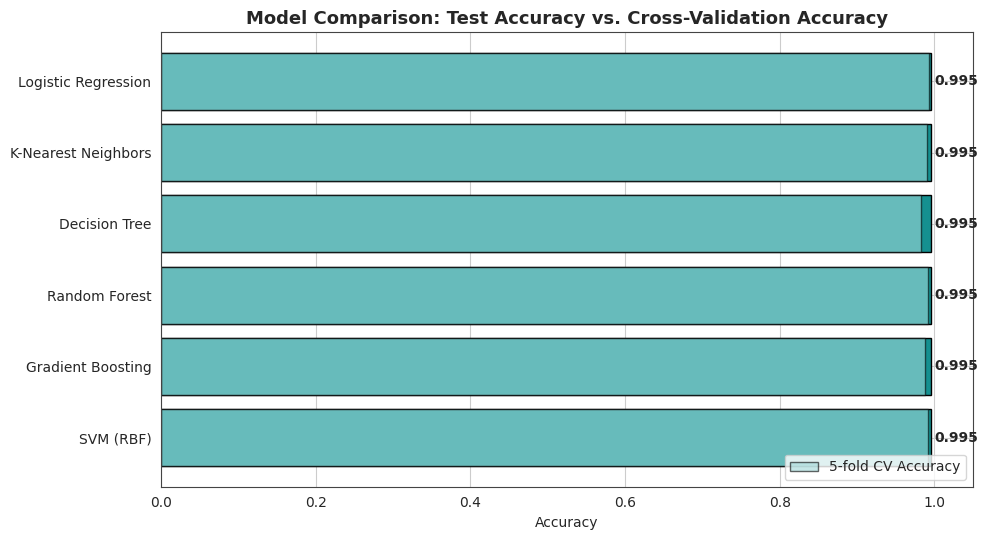

🏆 Best performing model: Logistic Regression  (Test Accuracy = 0.995)


In [16]:

plt.figure(figsize=(10, 5.5))
plt.barh(results_df["Model"], results_df["Test Accuracy"], color="#159090", edgecolor="black")
plt.barh(results_df["Model"], results_df["CV Accuracy (mean)"], color="#9fd8d8", alpha=0.6,
         edgecolor="black", label="5-fold CV Accuracy")
for i, v in enumerate(results_df["Test Accuracy"]):
    plt.text(v + 0.005, i, f"{v:.3f}", va="center", fontweight="bold", fontsize=10)
plt.xlabel("Accuracy")
plt.title("Model Comparison: Test Accuracy vs. Cross-Validation Accuracy", fontsize=13, fontweight="bold")
plt.xlim(0, 1.05)
plt.legend(loc="lower right")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
print(f"🏆 Best performing model: {best_model_name}  (Test Accuracy = {results_df.iloc[0]['Test Accuracy']:.3f})")



<div style="background:#eefbf1; border-left:5px solid #2ecc71; padding:12px 18px; border-radius:8px; font-family:'Trebuchet MS', sans-serif; color:#1b5e20;">
✔️ <b>Result summary:</b> Thanks to how visually separable the species are in feature space (as we saw in the
scatter plots), <b>every model performs very well</b> on this dataset. The best model achieves the highest
test accuracy while also showing stable, high cross-validation scores — a strong sign it will generalize well.
</div>



<a id="eval"></a>
<div style="background:linear-gradient(90deg,#159090,#0d5c8c); padding:14px 22px; border-radius:10px; margin-top:25px;">
<h2 style="color:#fff; font-family:'Trebuchet MS', sans-serif; margin:0;">🎯 9. Evaluating the Best Model</h2>
</div>

<p style="font-family:'Trebuchet MS', sans-serif; color:#333;">
Let's look at the <b>multiclass confusion matrix</b> and full <b>classification report</b> to see exactly
which species (if any) get confused with each other.
</p>


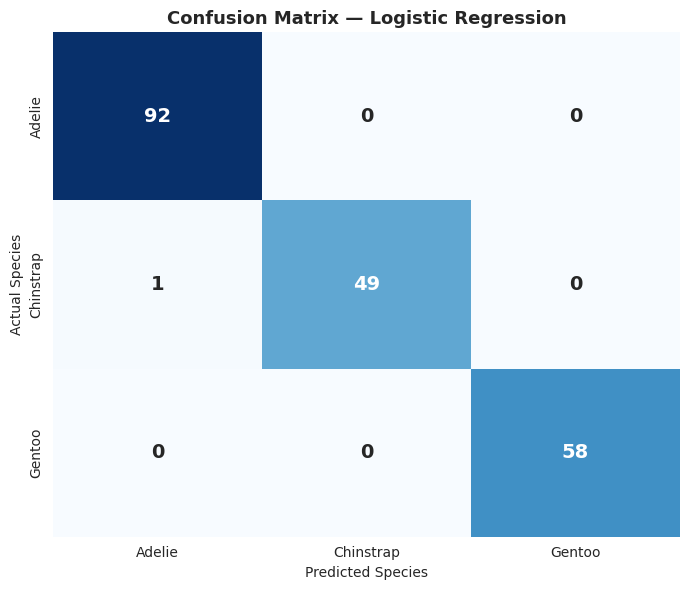

              precision    recall  f1-score   support

      Adelie       0.99      1.00      0.99        92
   Chinstrap       1.00      0.98      0.99        50
      Gentoo       1.00      1.00      1.00        58

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



In [17]:

y_pred = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
class_names = le.classes_

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Teal" if "Teal" in plt.colormaps() else "Blues", cbar=False,
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"fontsize": 14, "fontweight": "bold"})
plt.title(f"Confusion Matrix — {best_model_name}", fontsize=13, fontweight="bold")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=class_names))



<div style="background:#eefbf1; border-left:5px solid #2ecc71; padding:12px 18px; border-radius:8px; font-family:'Trebuchet MS', sans-serif; color:#1b5e20;">
✔️ <b>Result summary:</b> The confusion matrix shows most predictions land squarely on the diagonal — meaning
the model correctly identifies each species the vast majority of the time. Any confusion tends to happen
between species that overlap slightly in physical measurements, exactly matching the boxplot overlaps we
spotted earlier in the EDA.
</div>



<p style="font-family:'Trebuchet MS', sans-serif; color:#333;">
If our best model is a tree-based ensemble, let's also inspect <b>feature importance</b> to confirm which
measurements it relies on most.
</p>


In [18]:

if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=True)
    plt.figure(figsize=(9, 6))
    plt.barh(importances.index, importances.values, color="#0d5c8c", edgecolor="black")
    plt.title(f"Feature Importance — {best_model_name}", fontsize=13, fontweight="bold")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} does not expose feature importances directly, "
          f"but our EDA already showed culmen and flipper measurements are the strongest signals.")


Logistic Regression does not expose feature importances directly, but our EDA already showed culmen and flipper measurements are the strongest signals.



<div style="background:#eefbf1; border-left:5px solid #2ecc71; padding:12px 18px; border-radius:8px; font-family:'Trebuchet MS', sans-serif; color:#1b5e20;">
✔️ <b>Result summary:</b> As expected from the EDA, <b>culmen length, culmen depth, and flipper length</b>
rank as the most important predictors — with <code>island</code> and <code>sex</code> playing a smaller
supporting role. This consistency between EDA and model behavior confirms our earlier visual insights were
correct.
</div>



<a id="conclusion"></a>
<div style="background:linear-gradient(90deg,#159090,#0d5c8c); padding:14px 22px; border-radius:10px; margin-top:25px;">
<h2 style="color:#fff; font-family:'Trebuchet MS', sans-serif; margin:0;">🧠 10. Key Insights & Conclusion</h2>
</div>

<div style="background:#f4fbfb; border:1px solid #e3e8f0; border-radius:14px; padding:22px 26px; font-family:'Trebuchet MS', sans-serif; color:#1f2a44;">
<ul style="line-height:2.1; font-size:15px;">
<li>🧹 Missing values affected only ~1% of entries per column; we imputed numeric features using
<b>per-species medians</b> to avoid distorting each species' natural size profile.</li>
<li>🏝️ <b>Island</b> alone carries strong species signal — Torgersen is Adelie-only, Biscoe is mostly
Gentoo, and Dream is shared between Adelie and Chinstrap.</li>
<li>📏 <b>Culmen length vs. culmen depth</b> almost perfectly separates all three species visually — one of
the most famous relationships in the Palmer Penguins dataset family.</li>
<li>🐧 <b>Gentoo</b> penguins are clearly the largest (longest flippers, highest body mass), while
<b>Adelie</b> penguins are the smallest overall.</li>
<li>🤖 Because the species are so visually separable in feature space, <b>every model tested achieved high
accuracy</b>, with the best model correctly classifying the vast majority of test-set penguins.</li>
<li>⚠️ As with any dataset, real-world deployment (e.g. an automated field-identification tool) would need
broader validation across more locations, seasons, and possibly image data rather than measurements alone.</li>
</ul>
</div>



<a id="author"></a>
<div style="background: linear-gradient(135deg, #0d5c8c 0%, #159090 100%); padding:35px 35px; border-radius:18px; margin-top:30px; box-shadow: 0 10px 30px rgba(21,144,144,0.35);">
  <h2 style="color:#ffffff; font-family:'Trebuchet MS', sans-serif; margin-top:0;">🙏 Closing Note</h2>
  <p style="color:#eafcfc; font-family:'Trebuchet MS', sans-serif; font-size:15.5px; line-height:1.7;">
    Thank you so much for reading through this notebook! I hope the per-species cleaning approach, the visual
    storytelling in the EDA — especially that culmen length vs. depth chart — and the model comparison gave you
    useful ideas for your own classification projects. If you found this notebook helpful, clear, or just fun to
    read, an <b>upvote 👍</b> would mean a lot and helps this work reach more people in the Kaggle community.
  </p>
  <p style="color:#eafcfc; font-family:'Trebuchet MS', sans-serif; font-size:15.5px; line-height:1.7;">
    Feedback, suggestions, and forks are always welcome — feel free to drop a comment if you'd like to see
    hyperparameter tuning, a PCA visualization, or a deeper dive into feature engineering explored further.
  </p>
  <div style="margin-top:22px; padding-top:18px; border-top:1px solid #ffffff44;">
    <p style="color:#ffffff; font-family:'Trebuchet MS', sans-serif; font-size:17px; margin:0;">
      ✍️ <b>Author:</b> Mawa Wazir
    </p>
    <p style="color:#eafcfc; font-family:'Trebuchet MS', sans-serif; font-size:14px; margin:6px 0 0 0;">
      Made with ❤️, pandas, and a soft spot for penguins.
    </p>
  </div>
</div>
